In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

tf.keras.utils.set_random_seed(42)

I0000 00:00:1790228772.111744     549 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790228778.148182     549 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:

# 1. 데이터 확인
df = pd.read_csv("moldset_labeled_cn7.csv")
print("데이터 크기:", df.shape)
print("라벨별 개수:\n", df["PassOrFail"].value_counts())

# 0 = 양품, 1 = 불량
feature_cols = df.columns.drop(["Unnamed: 0", "PassOrFail"])
normal = df.loc[df["PassOrFail"] == 0, feature_cols]
defect = df.loc[df["PassOrFail"] == 1, feature_cols]


데이터 크기: (1211, 26)
라벨별 개수:
 PassOrFail
0    1194
1      17
Name: count, dtype: int64


In [3]:

# 2. 양품을 학습용과 평가용으로 분리
normal_train, normal_test = train_test_split(
    normal, test_size=0.4, random_state=42, shuffle=True
)

# 평가 데이터는 스케일러 학습에 사용하지 않음
scaler = MinMaxScaler()
x_train = scaler.fit_transform(normal_train).astype("float32")
x_normal_test = scaler.transform(normal_test).astype("float32")
x_defect_test = scaler.transform(defect).astype("float32")

In [5]:

# 3. 양품 복원용 오토인코더
model = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dropout(0.3),
    Dense(15, activation="relu"),
    Dense(5, activation="relu"),
    Dense(15, activation="relu"),
    Dense(x_train.shape[1], activation="linear")
])

model.compile(
    loss="mse",
    optimizer=Adam(learning_rate=0.01),
    metrics=["accuracy"]
)

history = model.fit(
    x_train, x_train,
    batch_size=30,
    epochs=30,
    validation_split=0.2,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=7,
            mode="min",
            restore_best_weights=True
        )
    ],
    verbose=1
)


Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1084 - loss: 0.1898 - val_accuracy: 0.4306 - val_loss: 0.0442
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2570 - loss: 0.0374 - val_accuracy: 0.0486 - val_loss: 0.0311
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1783 - loss: 0.0317 - val_accuracy: 0.4306 - val_loss: 0.0280
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3881 - loss: 0.0307 - val_accuracy: 0.4306 - val_loss: 0.0273
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3881 - loss: 0.0302 - val_accuracy: 0.4306 - val_loss: 0.0265
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3881 - loss: 0.0286 - val_accuracy: 0.4306 - val_loss: 0.0233
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4038 - loss: 0.0255 - val_accuracy: 0.5556 - val_loss: 0.0199
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4441 - loss: 0.0228 - val_accuracy: 0.4444 - val_loss

In [7]:

# 4. 학습 양품의 복원 오차로 임계값 계산
train_pred = model.predict(x_train, verbose=0)
train_mse = np.mean(np.square(train_pred - x_train), axis=1)
threshold = train_mse.mean() + 5 * train_mse.std()
print("복원 오차 임계값:", threshold)

복원 오차 임계값: 0.08728493098169565


In [9]:

# 5. 평가: 양품=0, 불량=1
x_test = np.concatenate([x_normal_test, x_defect_test])
y_true = np.concatenate([
    np.zeros(len(x_normal_test), dtype=int),
    np.ones(len(x_defect_test), dtype=int)
])

test_pred = model.predict(x_test, verbose=0)
test_mse = np.mean(np.square(test_pred - x_test), axis=1)
y_pred = (test_mse > threshold).astype(int)

print("혼동행렬 [[양품→양품, 양품→불량], [불량→양품, 불량→불량]]:")
print(confusion_matrix(y_true, y_pred, labels=[0, 1]))
print(classification_report(
    y_true, y_pred, labels=[0, 1],
    target_names=["양품", "불량"], zero_division=0
))

혼동행렬 [[양품→양품, 양품→불량], [불량→양품, 불량→불량]]:
[[477   1]
 [ 13   4]]
              precision    recall  f1-score   support

          양품       0.97      1.00      0.99       478
          불량       0.80      0.24      0.36        17

    accuracy                           0.97       495
   macro avg       0.89      0.62      0.67       495
weighted avg       0.97      0.97      0.96       495



/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/op

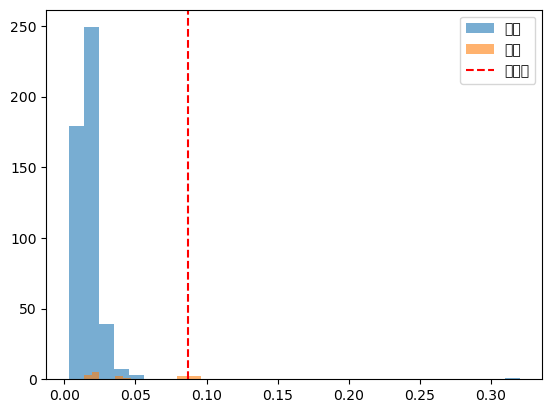

In [10]:
plt.hist(test_mse[y_true == 0], bins=30, alpha=0.6, label="양품")
plt.hist(test_mse[y_true == 1], bins=15, alpha=0.6, label="불량")
plt.axvline(threshold, color="red", linestyle="--", label="임계값")
plt.legend()
plt.show()